In [1]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
def plot_bar_chart(df, x, hue, title, stat= 'Percent', facet=None, stacked_by=None):
    df = df[df['statistics'] == stat]
    plt.figure(figsize=(10,6))    
    
    if stacked_by:
        # group and pivot for stacked bar chart (use mean for percentages)
        if facet:
            pivot_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            for fac in df[facet].unique():
                sub = pivot_df[pivot_df[facet] == fac]
                pivot = sub.pivot(index=x, columns=hue, values='value').fillna(0)
                ax = pivot.plot(kind='bar', stacked=True, ax=plt.gca())
                plt.legend(title=stacked_by)
                plt.xticks(rotation=90)
                # add labels to each bar segment
                for cidx, col in enumerate(pivot_df.columns):
                    for ridx, val in enumerate(pivot_df[col]):
                        if val > 0:
                            bottom = pivot_df.iloc[ridx, :cidx].sum()
                            ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
        else: 
            pivot_df = df.groupby([x, hue])['value'].mean().unstack(fill_value=0)
            ax = pivot_df.plot(kind='bar', stacked=True, ax=plt.gca())
            plt.legend(title=stacked_by)
            plt.xticks(rotation=90)
            # Add labels to each bar segment
            for cidx, col in enumerate(pivot_df.columns):
                for ridx, val in enumerate(pivot_df[col]):
                    if val > 0:
                        bottom = pivot_df.iloc[ridx, :cidx].sum()
                        ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
    else:
        # regular bar chart
        if facet:
            agg_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            ax = sns.catplot(data=agg_df, x=x, y='value', hue=hue, col=facet, kind='bar', height=5, aspect=1.2)
            ax.set_titles(col_template="{col_name}")

            # add labels on bars
            for ax_i in ax.axes.flatten():
                ax_i.set_ylabel('Average Percentage')
                ax_i.set_xticklabels(ax_i.get_xticklabels(), rotation=90)
                for container in ax_i.containers:
                    ax_i.bar_label(container, fmt='%.1f', padding=2)
                    
            plt.subplots_adjust(top=0.85)
            plt.suptitle(title)

        else:
            agg_df = df.groupby([x, hue])['value'].mean().reset_index()
            ax = sns.barplot(data=agg_df, x=x, y='value', hue=hue)
            plt.xticks(rotation=90)

            # add labels on bars
            for container in ax.containers:
                ax.bar_label(container, fmt='%.1f', padding=2)
    
            plt.title(title)
            plt.xlabel(x)
            plt.ylabel('Average Percentage')
            plt.tight_layout()
            plt.show()

In [3]:
# Load the Parquet file
df = pq.read_table('../../data/healthcare-access/healthcare_access_2017.parquet').to_pandas()

In [4]:
# display df
df.head()

,geo,aboriginal_identity,age_group,gender,statistics,value,regular_medical_doctor_status,contact_with_health_professional_12mo,received_dental_care_3yr,healthcare_required_not_received_12mo
0,Canada,First Nations (North American Indian),15 to 24 years,Both sexes,Number of persons,85730.0,Has a regular medical doctor,None,None,None
1,Canada,First Nations (North American Indian),15 to 24 years,Both sexes,Percent,73.5,Has a regular medical doctor,None,None,None
2,Canada,First Nations (North American Indian),15 to 24 years,Both sexes,Number of persons,29410.0,Does not have a regular medical doctor,None,None,None
3,Canada,First Nations (North American Indian),15 to 24 years,Both sexes,Percent,25.2,Does not have a regular medical doctor,None,None,None
4,Canada,First Nations (North American Indian),15 to 24 years,Both sexes,Number of persons,2950.0,Does not have a regular medical doctor: no med...,None,None,None


# Regular Medical Doctor Status

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_67473/3972586280.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


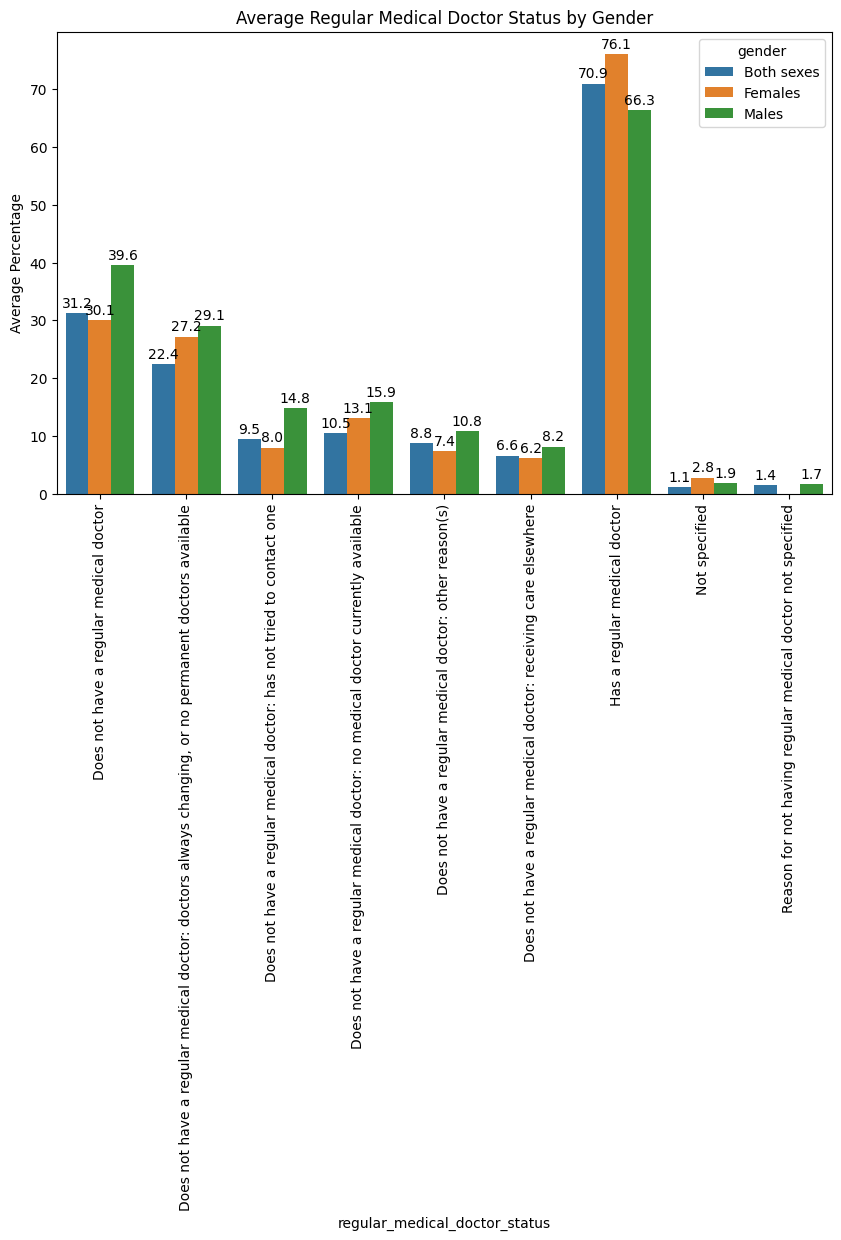

In [5]:
# plot regular_medical_doctor_status
plot_bar_chart(df,
    x='regular_medical_doctor_status',
    hue='gender',
    title='Average Regular Medical Doctor Status by Gender',
    stat='Percent',
    stacked_by=None
)

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_67473/3972586280.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


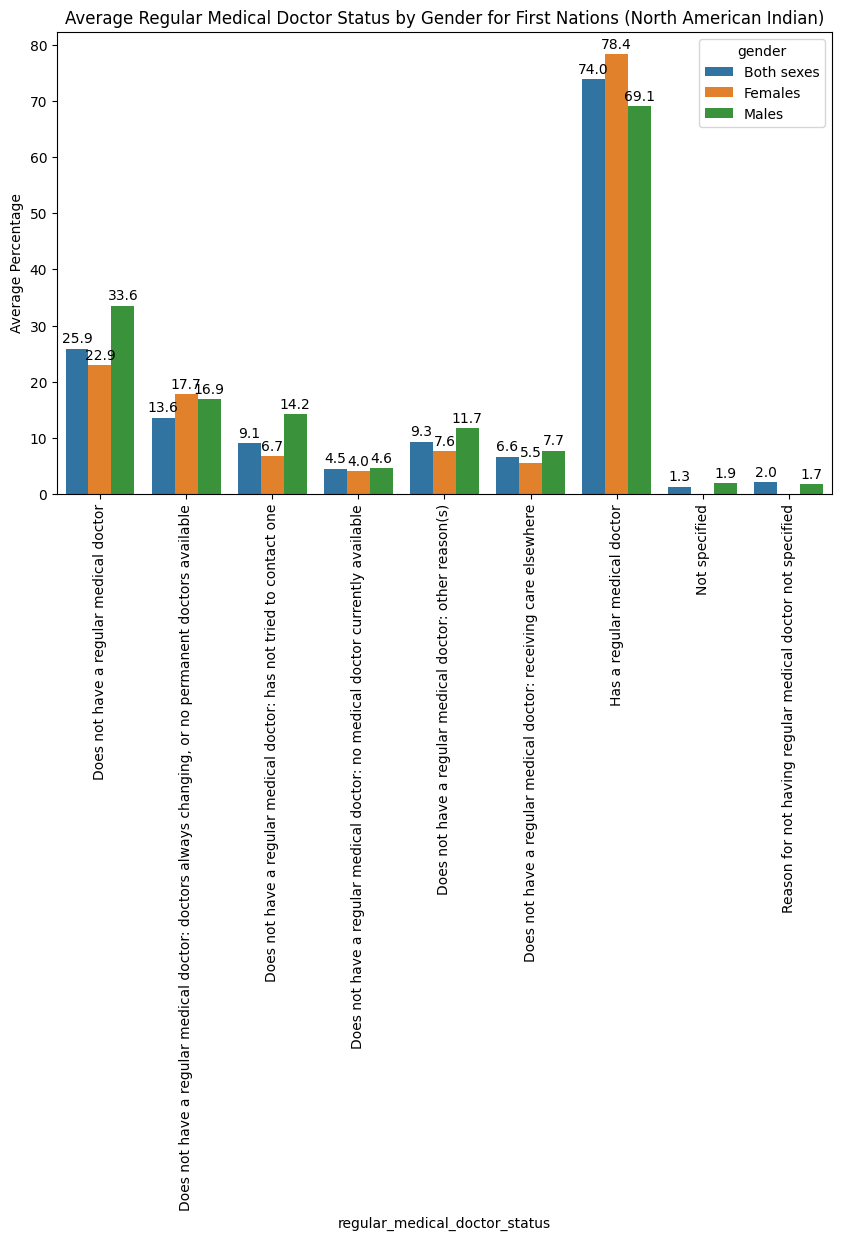

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_67473/3972586280.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


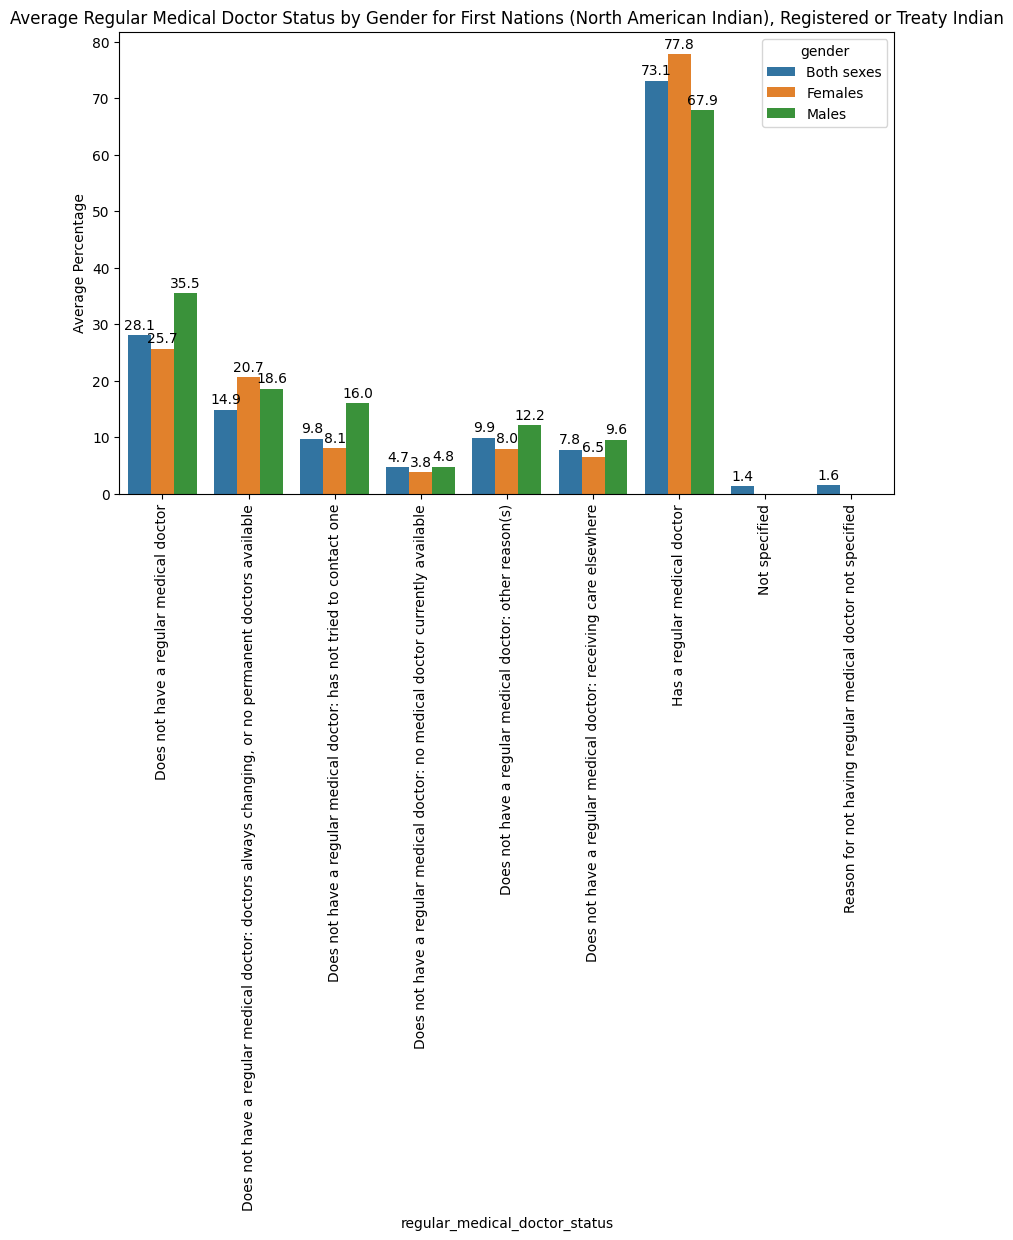

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_67473/3972586280.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


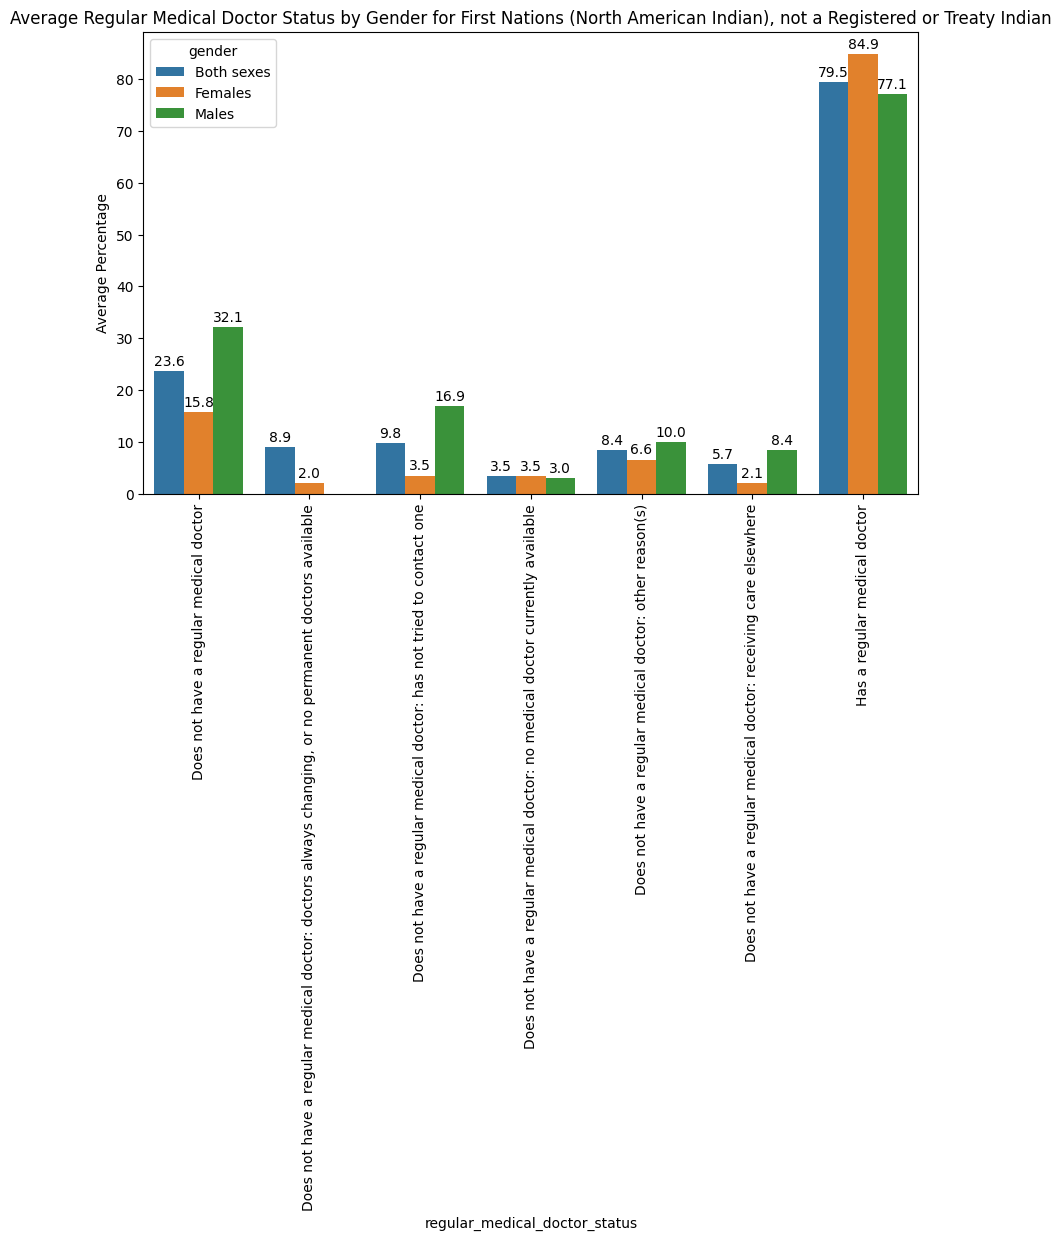

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_67473/3972586280.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


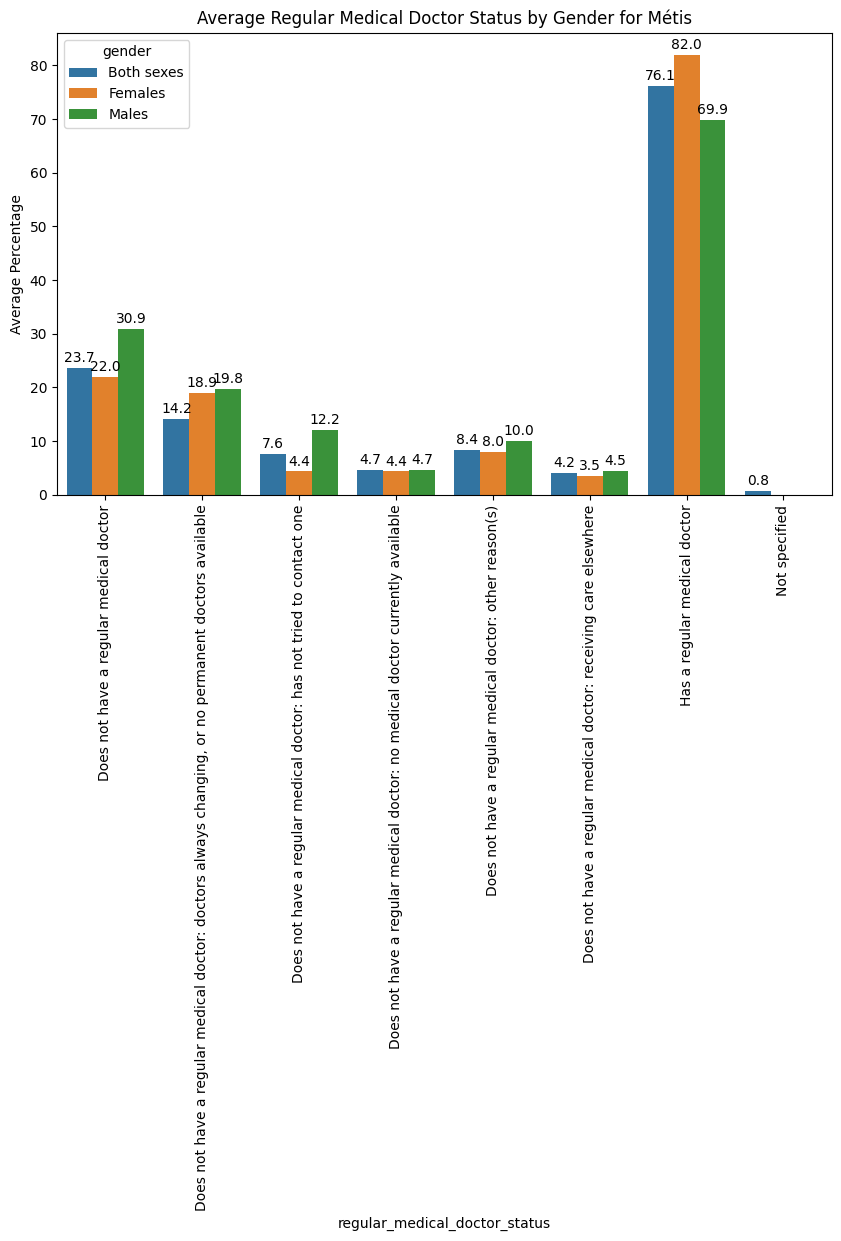

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_67473/3972586280.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


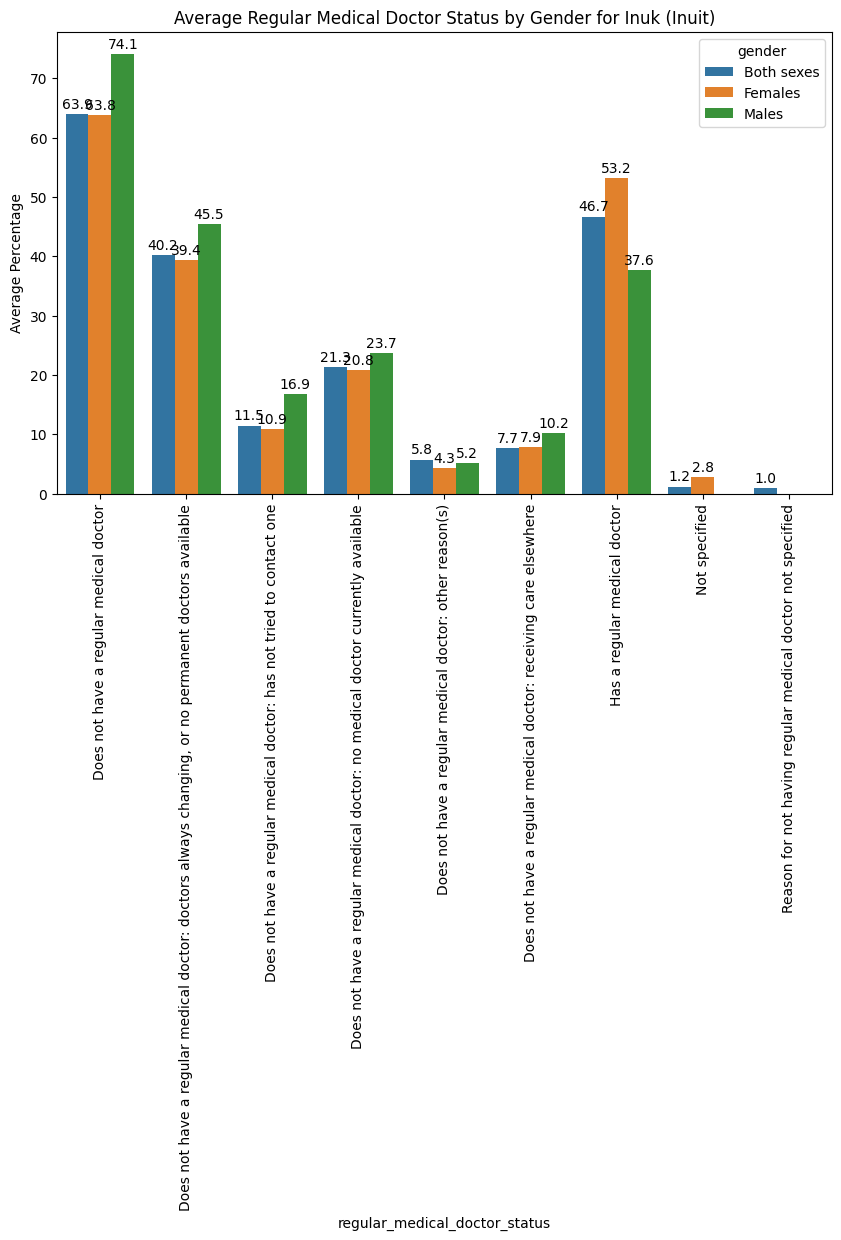

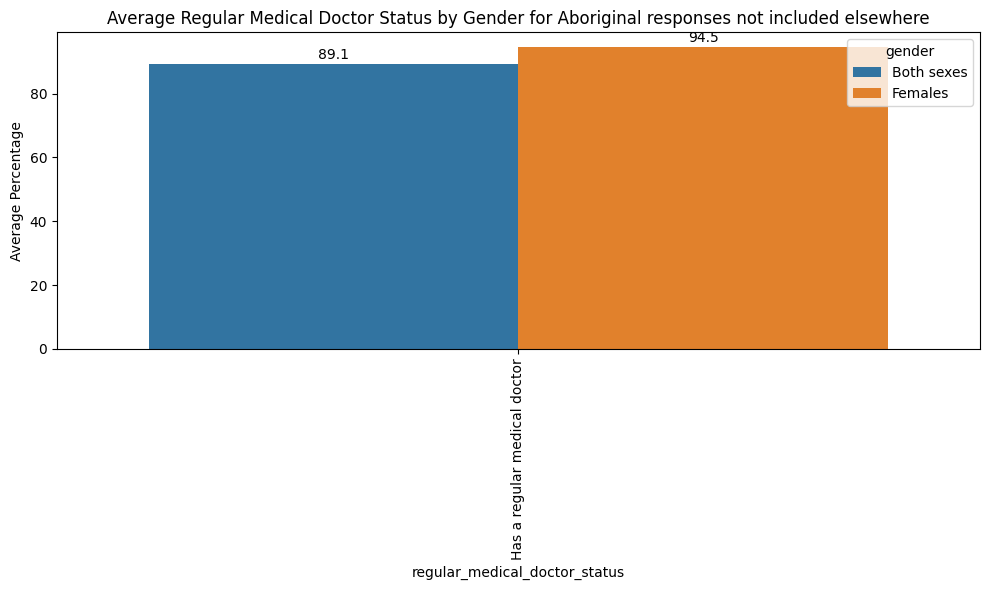

In [6]:
for ind_identity in df['aboriginal_identity'].unique():
    df_ind = df[df['aboriginal_identity'] == ind_identity]
    plot_bar_chart(df_ind,
    x='regular_medical_doctor_status',
    hue='gender',
    title='Average Regular Medical Doctor Status by Gender for '+ind_identity,
    stat='Percent',
    stacked_by=None,
)

# Contact with health professional past 12 months

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_67473/3972586280.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


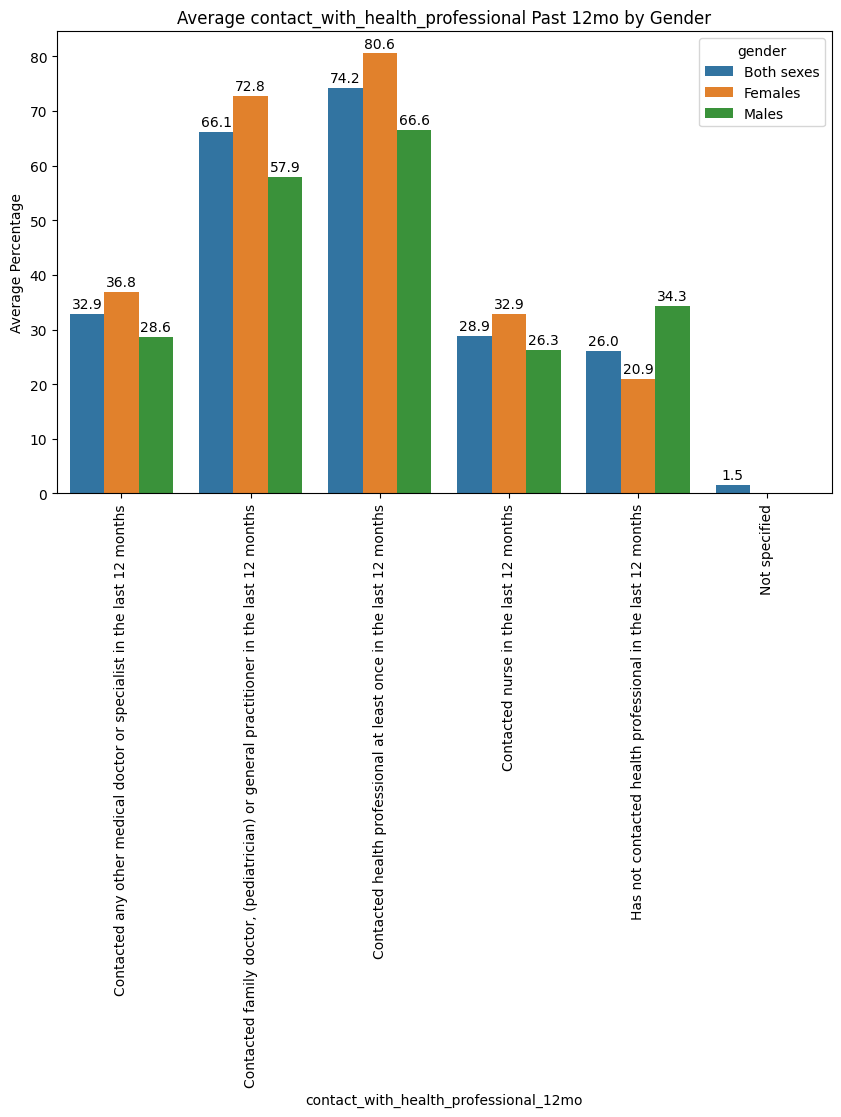

In [7]:
plot_bar_chart(df,
    x='contact_with_health_professional_12mo',
    hue='gender',
    title='Average contact_with_health_professional Past 12mo by Gender',
    stat='Percent',
    stacked_by=None
)

# Dental Care Past 3 years

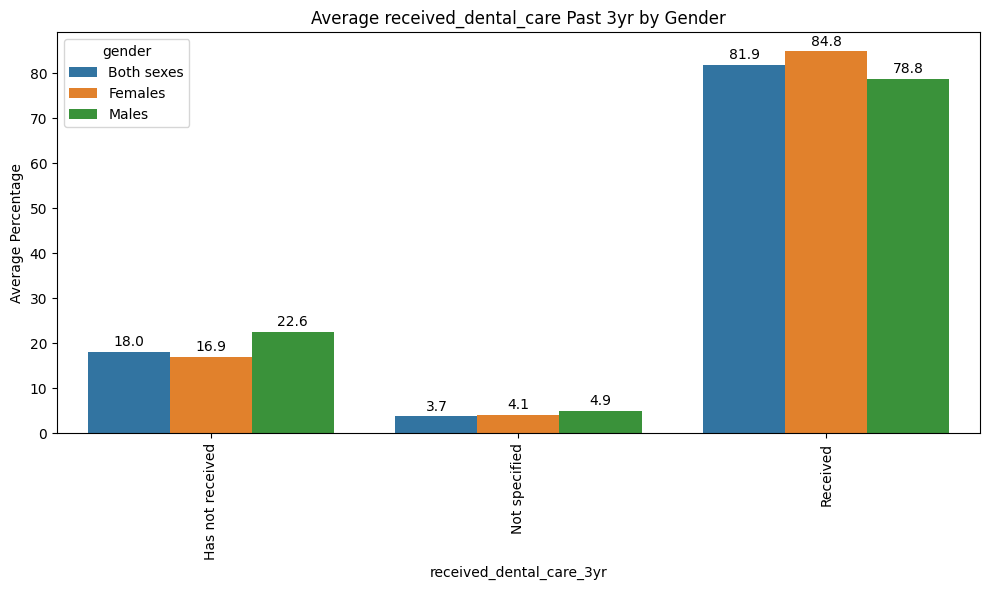

In [8]:
plot_bar_chart(df,
    x='received_dental_care_3yr',
    hue='gender',
    title='Average received_dental_care Past 3yr by Gender',
    stat='Percent',
    stacked_by=None
)

# Healthcare_required_not_received Past 12 months

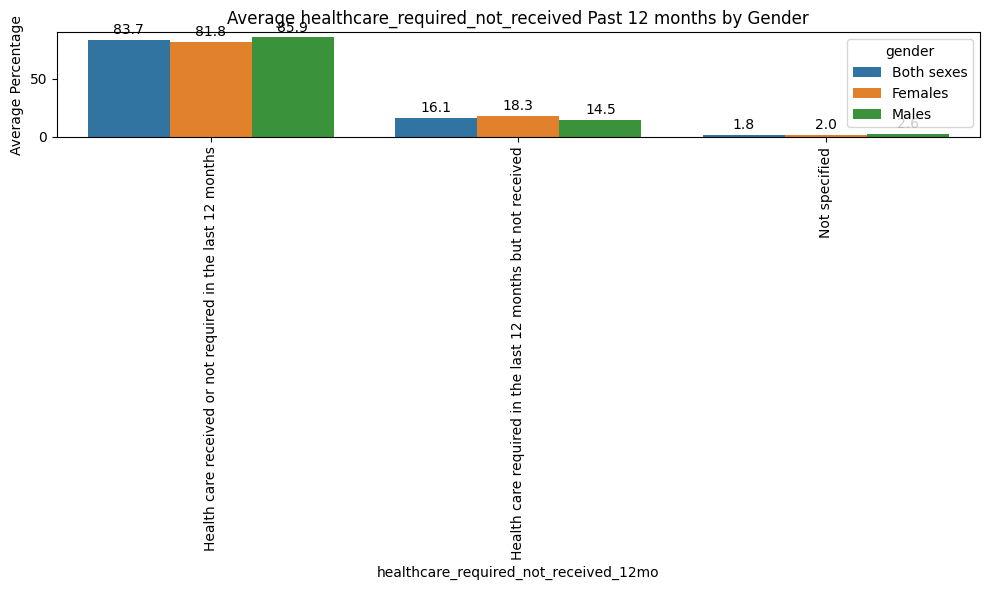

In [9]:
plot_bar_chart(df,
    x='healthcare_required_not_received_12mo',
    hue='gender',
    title='Average healthcare_required_not_received Past 12 months by Gender',
    stat='Percent',
    stacked_by=None
)